In [1]:
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import napari
import pickle

In [2]:
from skimage import data
from scipy import stats
from scipy import signal
from tifffile import tifffile
from os.path import sep
from matplotlib import pyplot as plt
import math
import matplotlib.colors as colors
import xarray as xr
import pandas as pd
import seaborn as sns
import json
import os
from scipy.ndimage import gaussian_filter1d

In [3]:
import SessionTools.two_photon as st2p

In [4]:
from fly2p_function_TQ.imaging_2p_preprocessing import combine_single_tiff, computeMotionShift, motionCorrection, low_pass_filter_TQ, high_pass_filter_TQ, averaging_frame, combine_single_tiff_ch1
from fly2p_function_TQ.imaging_2p_preprocessing import combine_PB_corresponding_ROI,get_raw_F,get_dff_array, normalizing_dff_array, combine_single_tiff_V2, combine_EB_corresponding_ROI,get_dff_array_running
from fly2p_function_TQ.imaging_2p_PVA_functions import PVA_radian_calcul, PVAangleToRoi, PVA_radian_to_angle, PVA_angle_to_radian, calcualteBumpAmplitude
from fly2p_function_TQ.imaging_2p_fictrac_imaging_alignment import downsample_heading_to_total_volume, offset_calculation,fictrack_signal_decoding,moving_wrapped_plot_by_offset
from fly2p_function_TQ.imaging_2p_fixed_heading_period_analysis import find_stop_period_on_heading

In [5]:
# Some key parameters for imaging analysis (for futuure should come from direct reading of metadata file)
volume_cycle = 2629
volume_time = 0.11414
volume_rate = 1/volume_time
slice_per_volume = 6
fictrack_sampling_rate = 50000

# 1 for cl, 0 for dark trial
trial_type = 1

# 1 for PB
brain_region = 1

In [6]:
green = 1
red = 0

In [7]:
time_array_imaging = np.arange(volume_cycle)/volume_rate

In [8]:
if green == 1:
    image_data_combined, tiff_file_sequence = combine_single_tiff(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/fly6-R55G08-SPARC-S-ASAP7y-006')
    image = image_data_combined

if red == 1:
    image_data_combined_red, tiff_file_sequence_red = combine_single_tiff_ch1(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/Pilot ASAP5/TQfly142-002')
    image_red = image_data_combined_red
image.shape

(2629, 6, 171, 372)

In [9]:
if green == 1:
    imgStack = xr.DataArray(image,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])
if red == 1:
    imgStack_red = xr.DataArray(image_red,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])

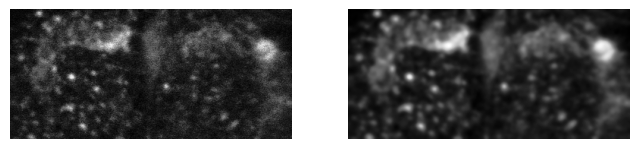

In [10]:
## Motion Correction setup
# Set reference image
stackMP = np.max(imgStack, axis=1) # max projection over volume
# Generate reference image
reference_num = np.int_(np.round(0.1 * volume_cycle))
refImg = np.mean(stackMP[0:reference_num,:,:],axis=0)

from scipy.ndimage import gaussian_filter
refImgFilt = gaussian_filter(refImg, sigma=2)

fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(refImg,cmap='Greys_r', origin='lower'); axs[0].axis('off');
axs[1].imshow(refImgFilt,cmap='Greys_r', origin='lower'); axs[1].axis('off');

In [11]:
if red == 1:
    ## Motion Correction setup
    # Set reference image
    stackMP_red = np.max(imgStack_red, axis=1) # max projection over volume
    # Generate reference image
    reference_num = np.int_(np.round(0.1 * volume_cycle))
    refImg_red = np.mean(stackMP_red[0:reference_num,:,:],axis=0)

    from scipy.ndimage import gaussian_filter 
    refImgFilt_red = gaussian_filter(refImg_red, sigma=2)

    fig, axs = plt.subplots(1,2,figsize=(8,4))
    axs[0].imshow(refImg_red,cmap='Greys_r', origin='lower'); axs[0].axis('off');
    axs[1].imshow(refImgFilt_red,cmap='Greys_r', origin='lower'); axs[1].axis('off');

perform motion correction on a single plane/max projection


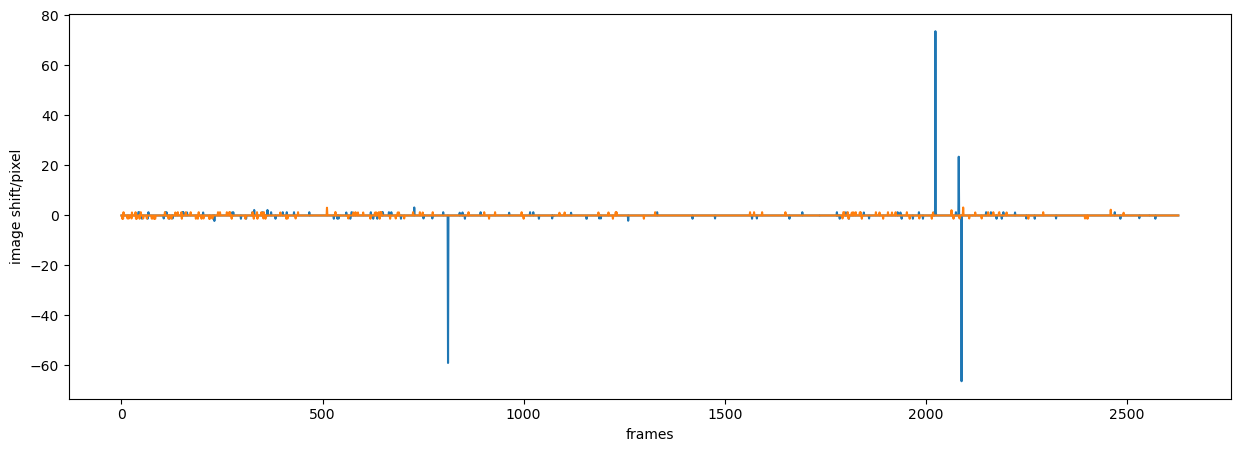

In [12]:
shift = computeMotionShift(stackMP, refImg, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [13]:
if red == 1:
    shift_red = computeMotionShift(stackMP_red, refImg_red, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [14]:
stack4dMC = motionCorrection(imgStack, shift)

In [15]:
if red == 1:
    stack4dMC_red = motionCorrection(imgStack_red, shift_red)

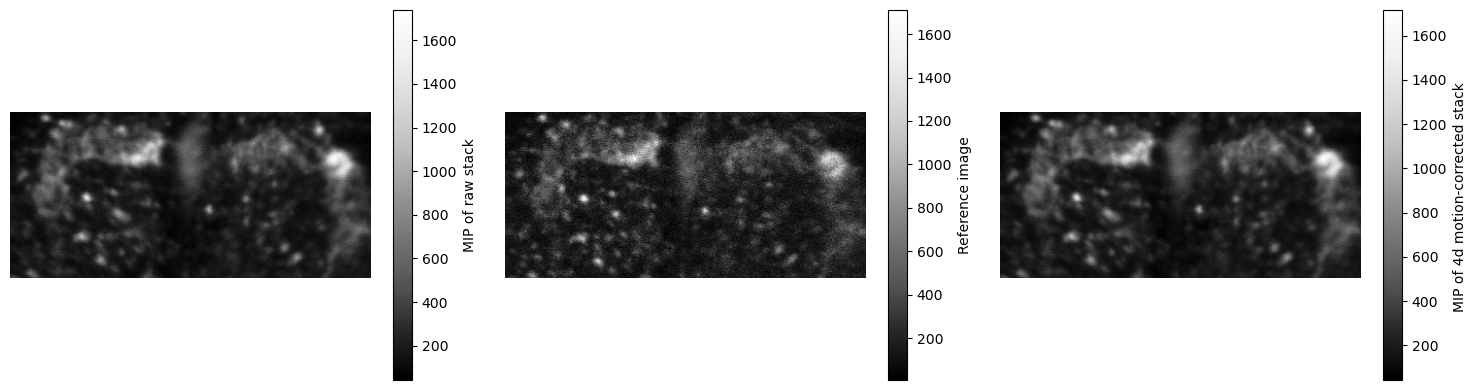

In [16]:
fig, axs = plt.subplots(1,3,figsize=(15,4))
cb = axs[0].imshow(imgStack.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[0], label='MIP of raw stack')
axs[0].axis('off');
cb = axs[1].imshow(refImg,cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[1], label='Reference image')
axs[1].axis('off');
cb = axs[2].imshow(stack4dMC.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[2], label='MIP of 4d motion-corrected stack ')
axs[2].axis('off');
fig.tight_layout()

In [17]:
if red == 1:
    imgStack_napari_red = np.expand_dims(imgStack_red, axis =0)
if green == 1:
    #stack4dMCTEST = np.expand_dims(stack4dMC, axis =0)
    imgStack_napari = np.expand_dims(imgStack, axis =0)

In [18]:
# Use this for EB roi
if brain_region == 0:
    ebnapari = st2p.preprocessing.napari_tools.EllipsoidBodySession().new_session(imgStack_napari.mean(axis=1))
# Use this for PB roi
else:
    viewer = napari.Viewer()
    new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #viewer.dims.ndisplay = 3

In [26]:
 new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #viewer.dims.ndisplay = 3
if brain_region == 0:
    ebnapari.make_phase_masks()

In [19]:
#For delta7 SPARC ASAP 7y Two ROI labels are drwan. 1 for axon terminal, 2 for dendritres 
label = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/R55G08_SPARC_ASAP7y/fly6/R55G08_SPARCS_ASAP_7y_ROI_2_fly6-006.tif")
label_background = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/R55G08_SPARC_ASAP7y/fly6/R55G08_SPARCS_ASAP_7y_ROI_1_fly6-006_background.tif")
if red == 1:
    label_red = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/delta7_ASAP5/napari_ROI_TQfly142/ROI_1_TQfly142_002_red.tif")
#viewer.add_labels(label, name='Labels_16_Roi'

In [20]:
#Load ROI and label from napari
#napari_roi_16 = viewer.layers['Labels_16_Roi'].data
if brain_region == 0: 
    napari_roi = label    
    napari_roi_background = label_background 
else:
    #napari_roi = label[0,:,:,:]
    #Start from TQfly081, easier way to save ROI
    napari_roi = np.squeeze(label , axis=0) 
    napari_roi_background = np.squeeze(label_background , axis=0) 
    if red == 1:
        napari_roi_red = np.squeeze(label_red , axis=0) 

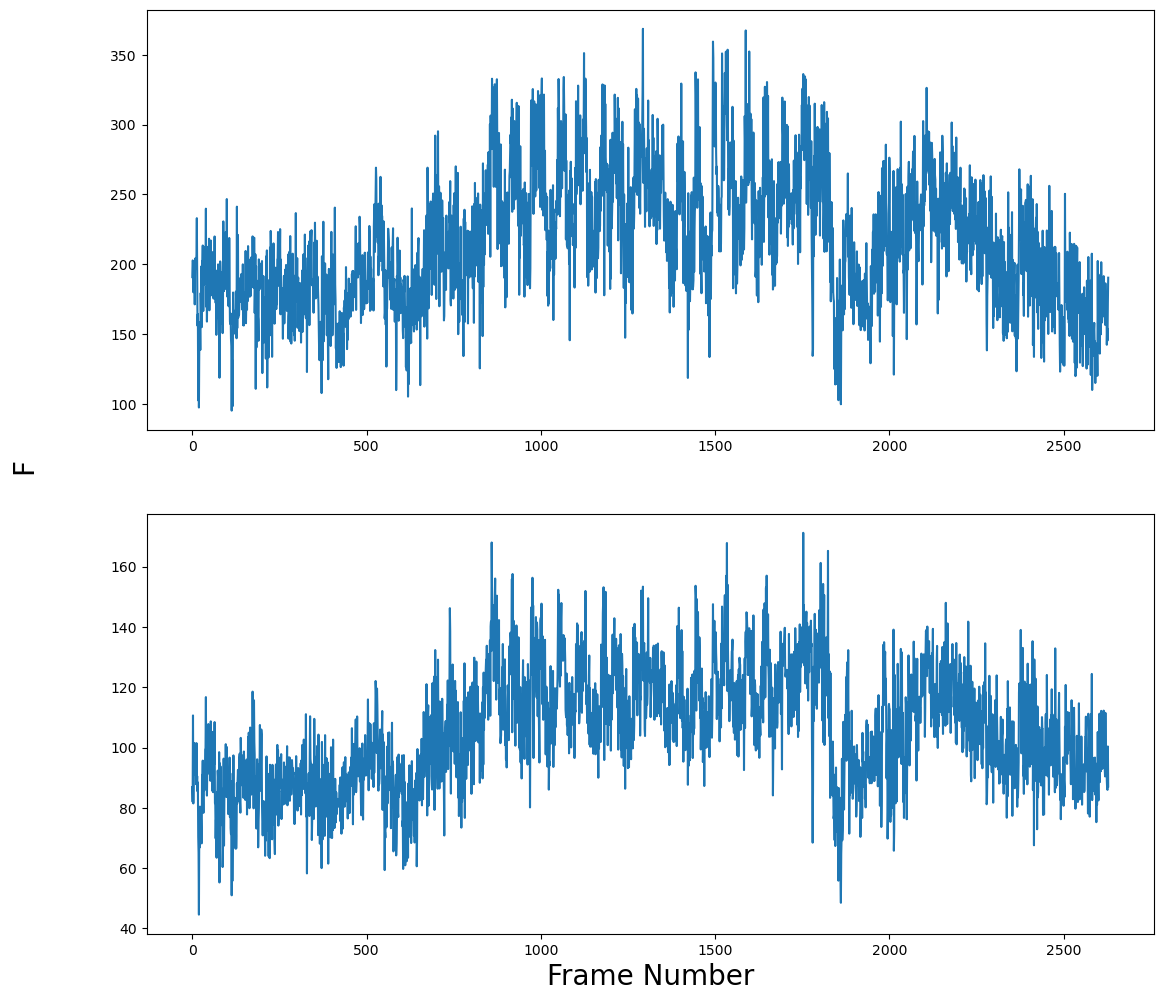

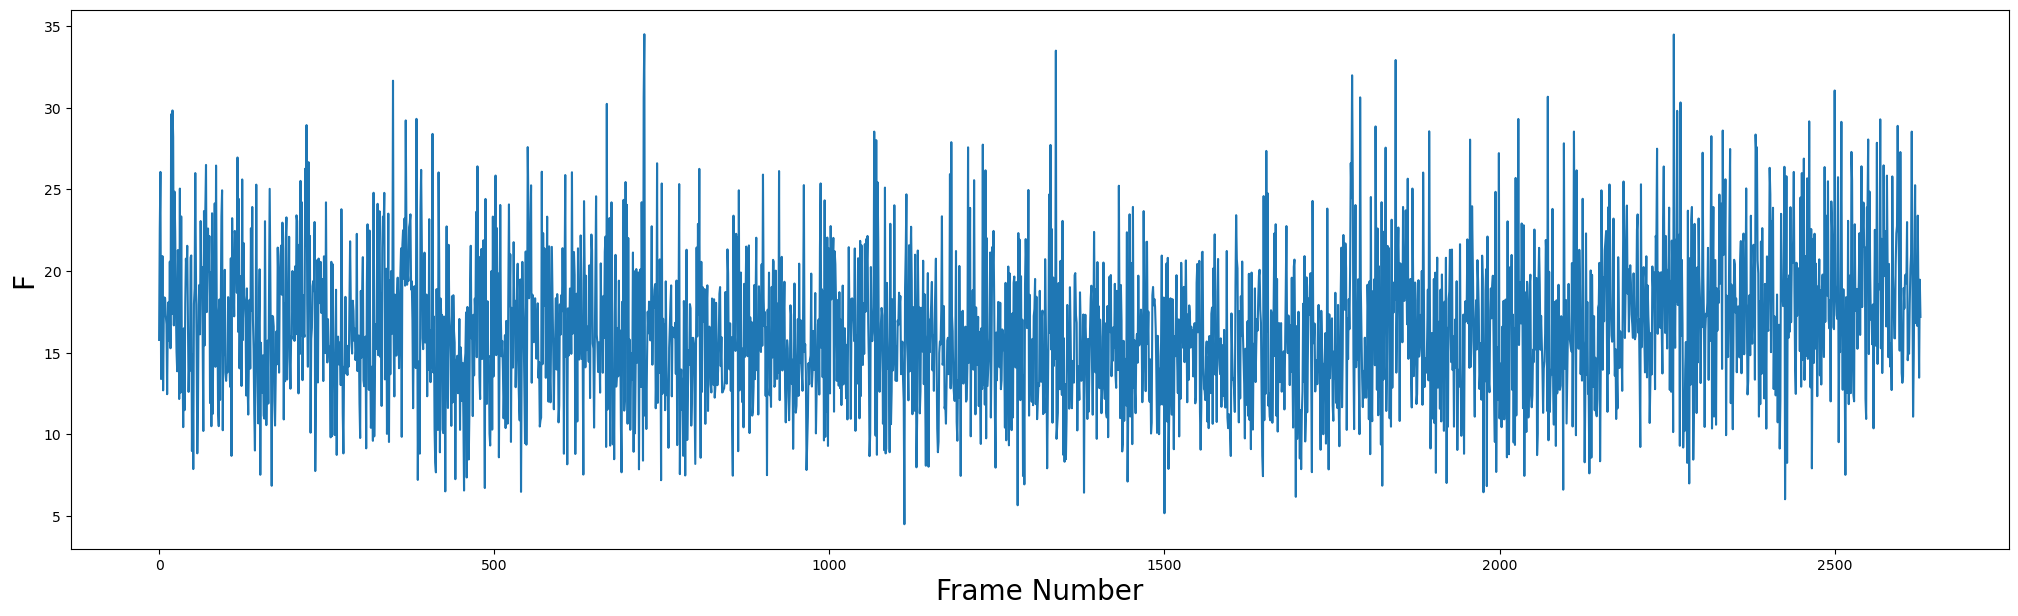

In [21]:
ROI_total_image = 2
ROI_total_background= 1
F_array = get_raw_F(ROI_total_image, napari_roi, imgStack)
F_array_background = get_raw_F(ROI_total_background, napari_roi_background, imgStack)
if red == 1:
    F_array_red = get_raw_F(ROI_total, napari_roi_red, imgStack_red)

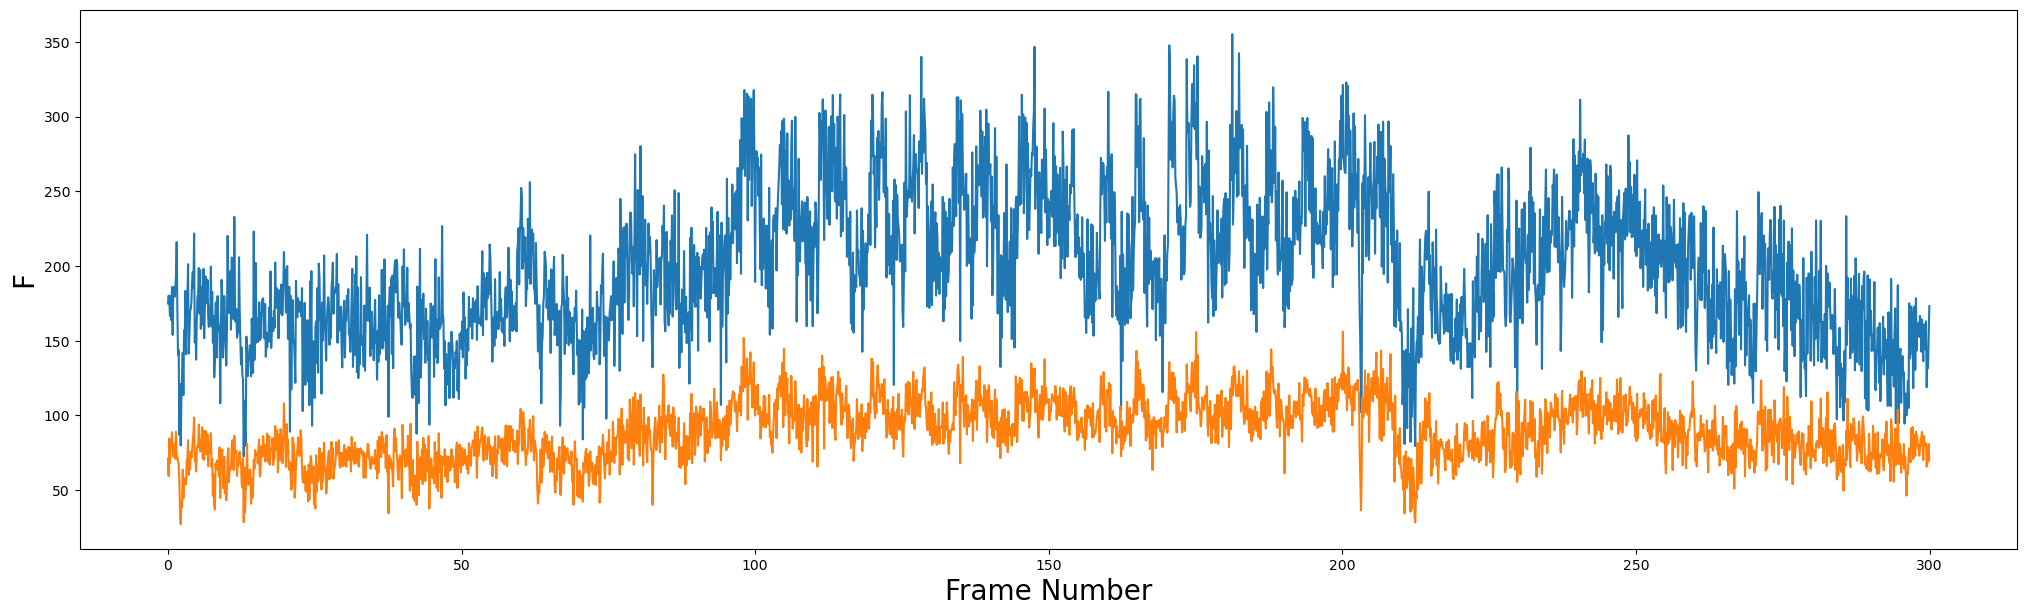

In [22]:
F_array_bg_subtracted = F_array - F_array_background
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, F_array_bg_subtracted)
plt.ylabel('F',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

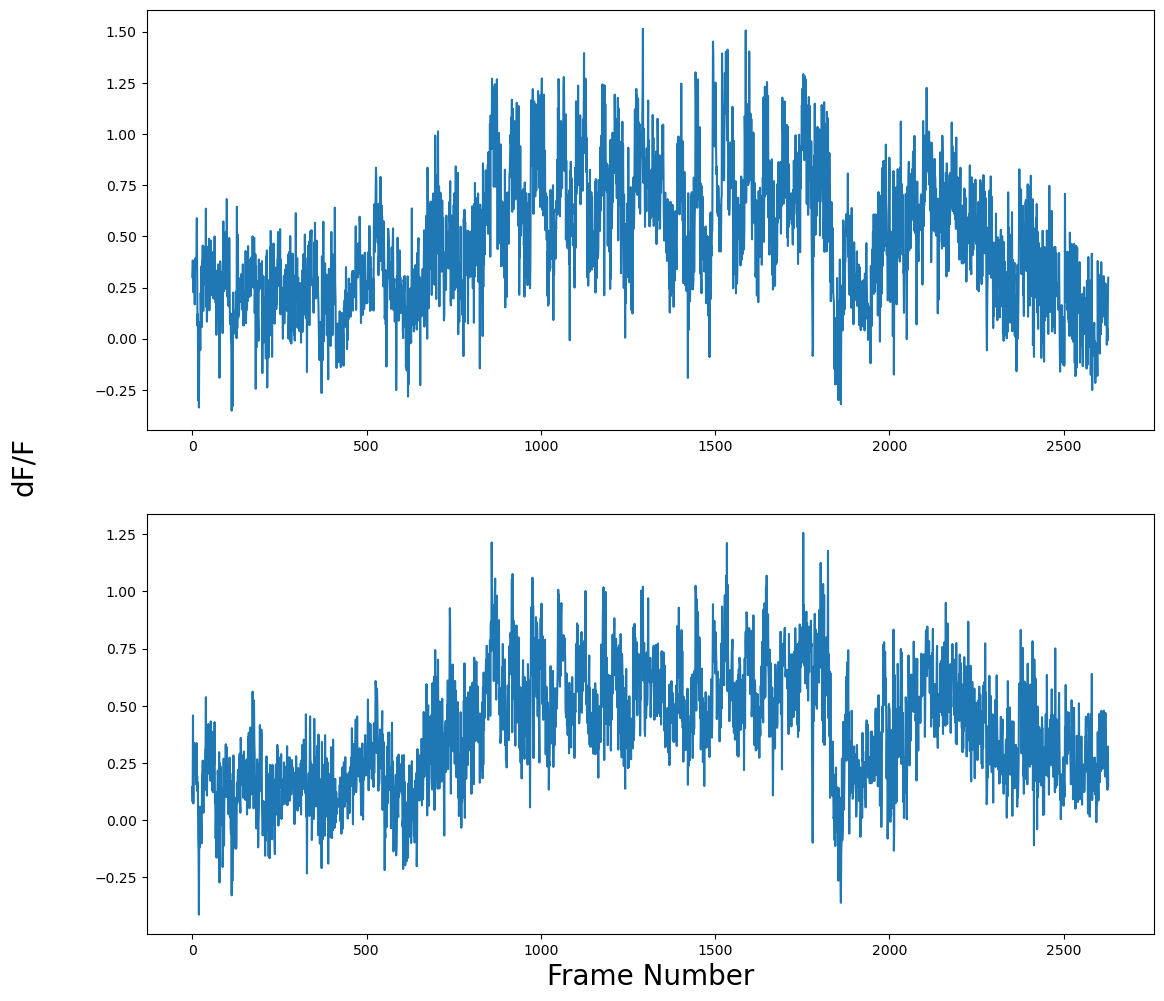

In [23]:
dF_F_array = get_dff_array(raw_F_array = F_array, ROI_num = ROI_total_image, F_zero_cutoff = 0.05, if_plot= 1)
if red == 1:
    dF_F_array_red = get_dff_array(raw_F_array = F_array_red, ROI_num = ROI_total, F_zero_cutoff = 0.05,if_plot= 1)

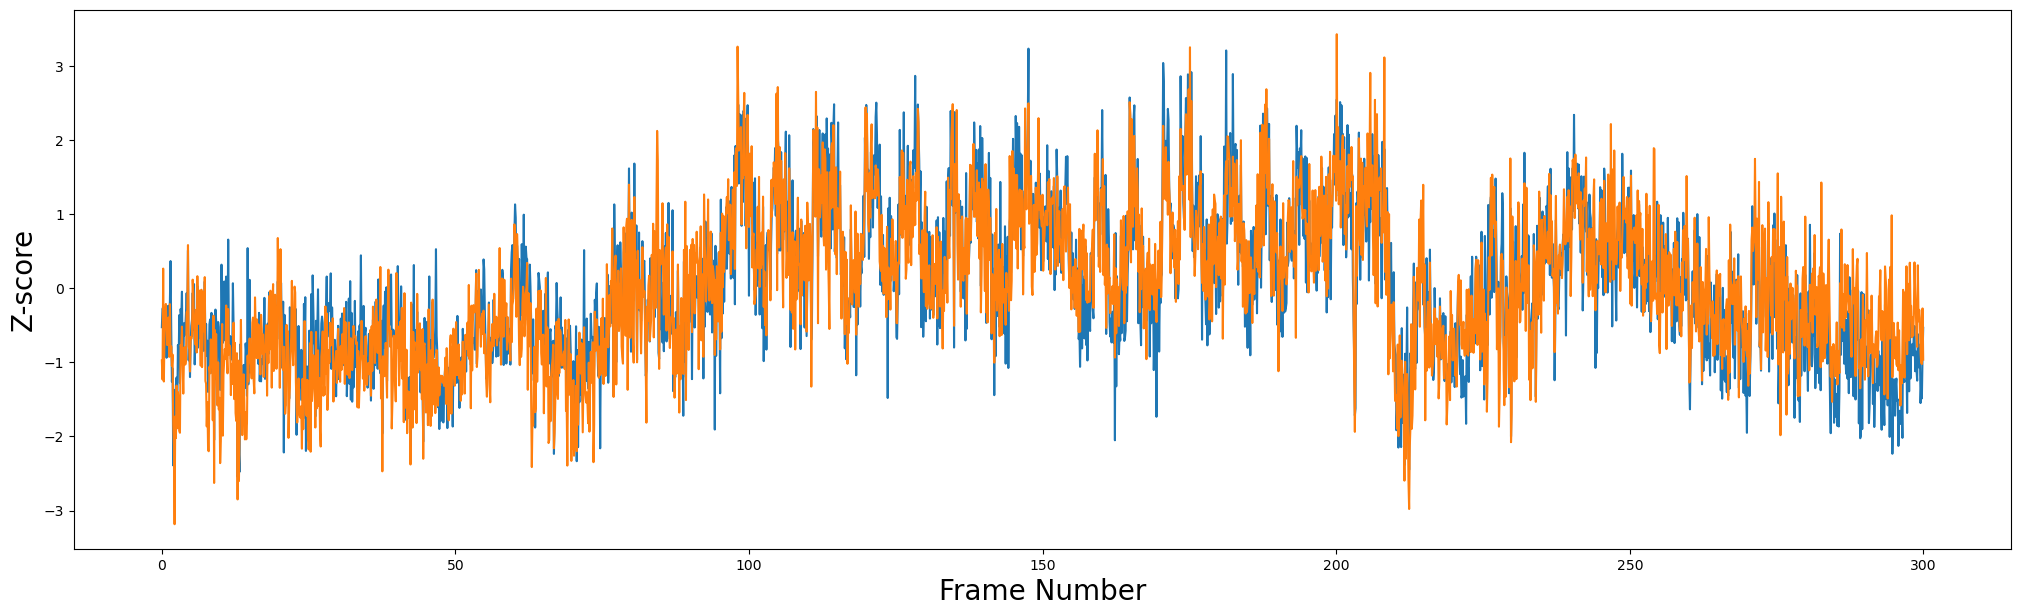

In [24]:
# Z-score: alternative way to calculate df/f
Z_score_array = np.zeros((imgStack['volumes [s]'].size, ROI_total_image))
F_sd = np.std(F_array, axis = 0)
F_mean = np.mean(F_array, axis = 0)
for z_index in range(ROI_total_image):
    Z_score_array [:,z_index] = (F_array[:,z_index] - F_mean[z_index])/F_sd[z_index]

plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, Z_score_array)
plt.ylabel('Z-score',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

In [25]:
voltage_recording = pd.read_csv('/home/tianhaoqiu/Desktop/fly6-R55G08-SPARC-S-ASAP7y-006/fly6-R55G08-SPARC-S-ASAP7y-006_Cycle00001_VoltageRecording_001.csv')

In [26]:
voltage_recording

,Time(ms),Input 2,Input 3,Input 4,Arena DAC
0,0.00,2.394104,3.272095,6.725159,7.273865
1,0.02,2.395630,3.272400,6.724548,7.273254
2,0.04,2.396851,3.274231,6.727295,7.274170
3,0.06,2.395020,3.272400,6.724854,7.273865
4,0.08,2.394409,3.271790,6.723022,7.272949
...,...,...,...,...,...
15004496,300089.92,3.962097,2.891541,6.866150,7.277527
15004497,300089.94,3.961487,2.891235,6.866150,7.275085
15004498,300089.96,3.960876,2.891541,6.866455,7.274780
15004499,300089.98,3.962097,2.892151,6.867676,7.275391


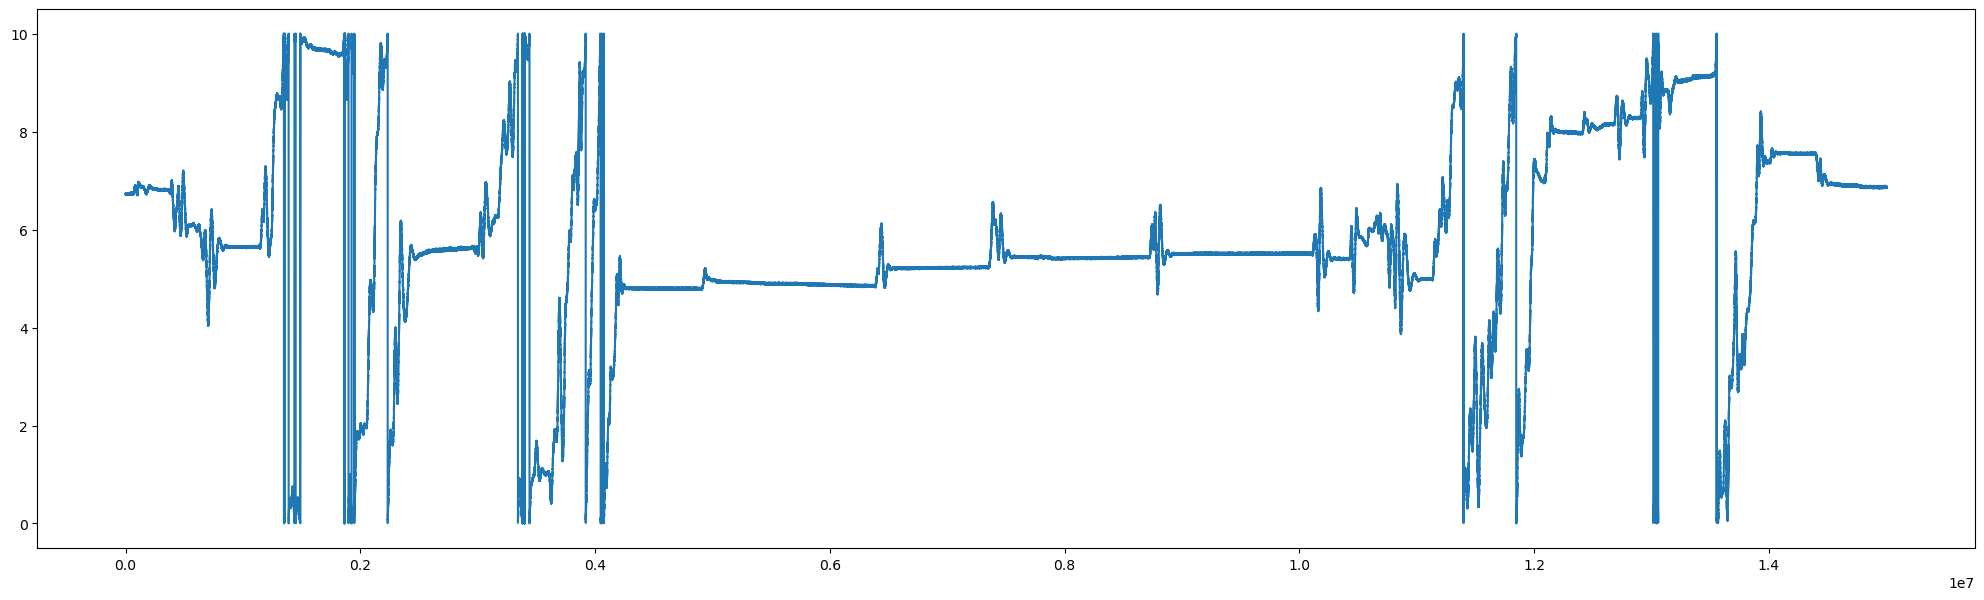

In [27]:
#Input4 = Heading, Input6 =x , Input7 =y
voltage_recording_heading = voltage_recording[' Input 4']
voltage_recording_forward = voltage_recording[' Input 2']
plt.figure(figsize= (25,7))
plt.plot(voltage_recording[' Input 4'])

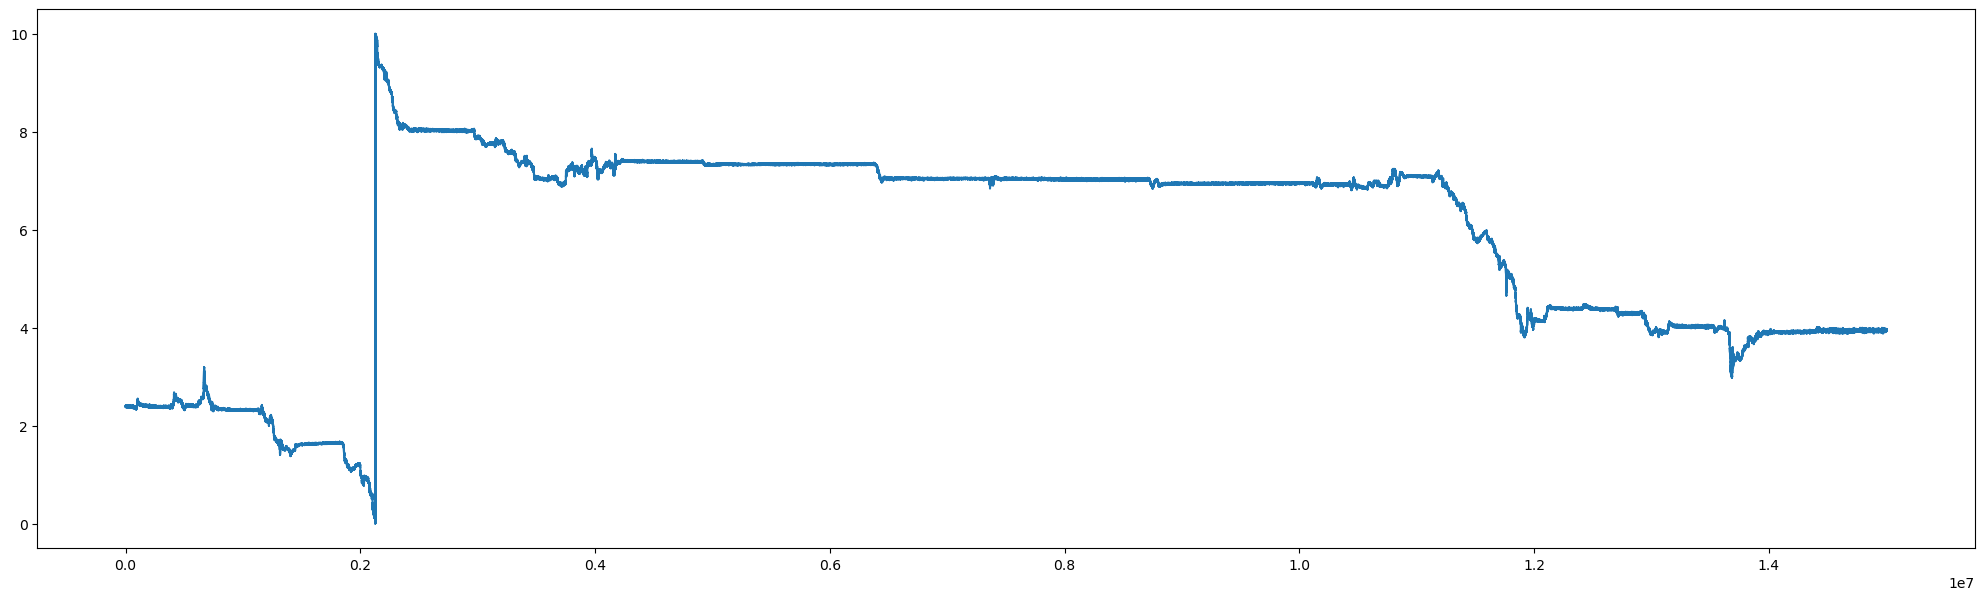

In [28]:
plt.figure(figsize= (25,7))
plt.plot(voltage_recording[' Input 2'])

In [29]:
heading_array = voltage_recording [' Input 4']
time_array_initial_fictrac = np.arange(len(heading_array))/fictrack_sampling_rate
head_array_filtered = low_pass_filter_TQ(heading_array, 100 ,fictrack_sampling_rate)
head_array_filtered = low_pass_filter_TQ(head_array_filtered, 100 ,fictrack_sampling_rate)
head_array_downsampled = downsample_heading_to_total_volume(volume_cycle, head_array_filtered)

In [30]:
forward_array = voltage_recording [' Input 2']
time_array_initial_fictrac = np.arange(len(forward_array))/fictrack_sampling_rate
forward_array_filtered = low_pass_filter_TQ(forward_array, 100 ,fictrack_sampling_rate)
forward_array_filtered = low_pass_filter_TQ(forward_array_filtered, 100 ,fictrack_sampling_rate)
forward_array_downsampled = downsample_heading_to_total_volume(volume_cycle, forward_array_filtered)

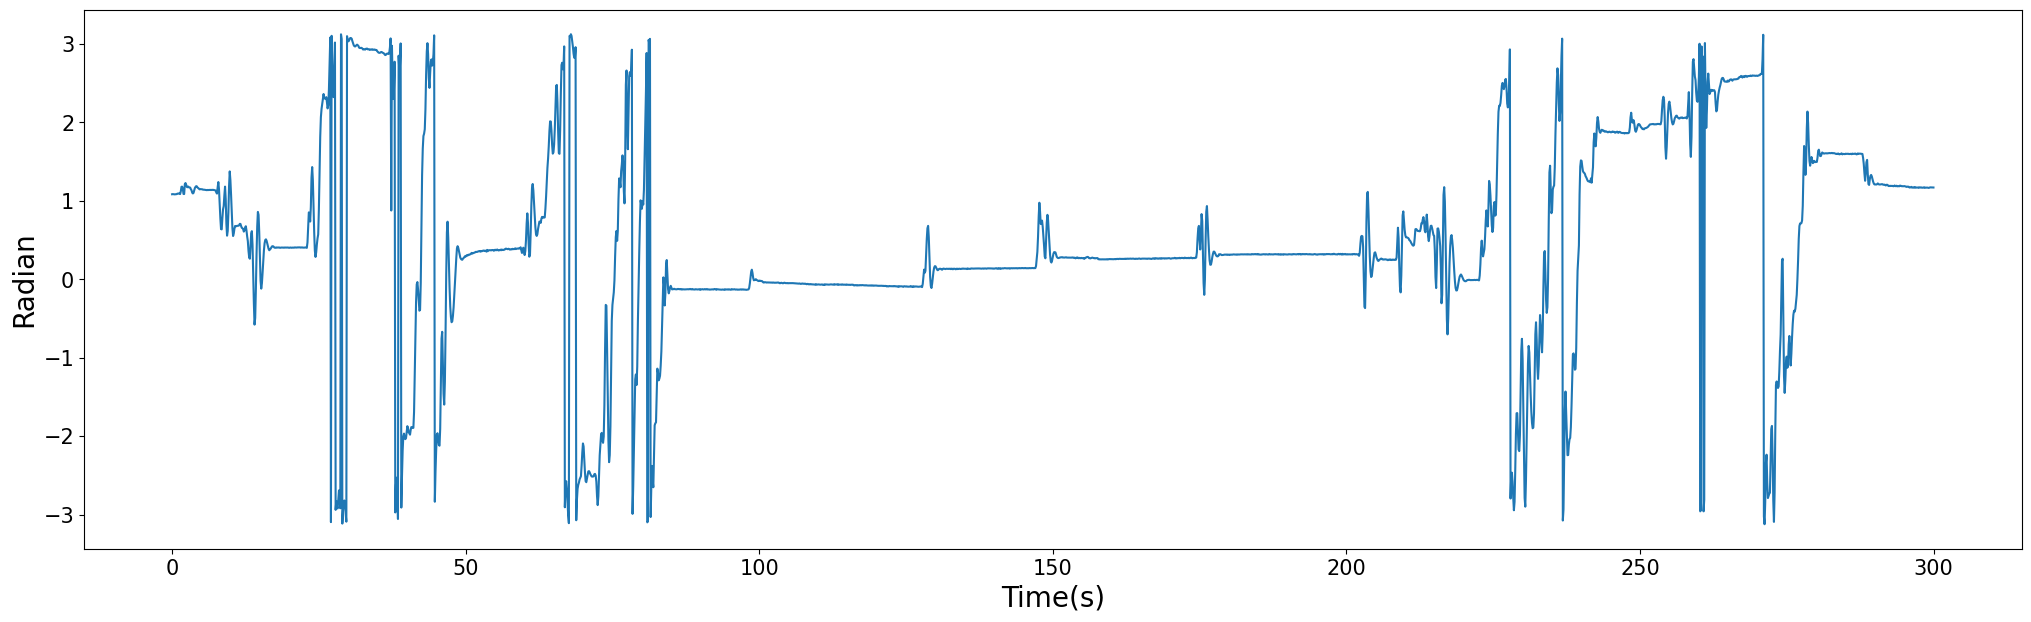

In [31]:
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,head_array_downsampled*np.pi*2/10-np.pi)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radian', fontsize=20)
plt.show()

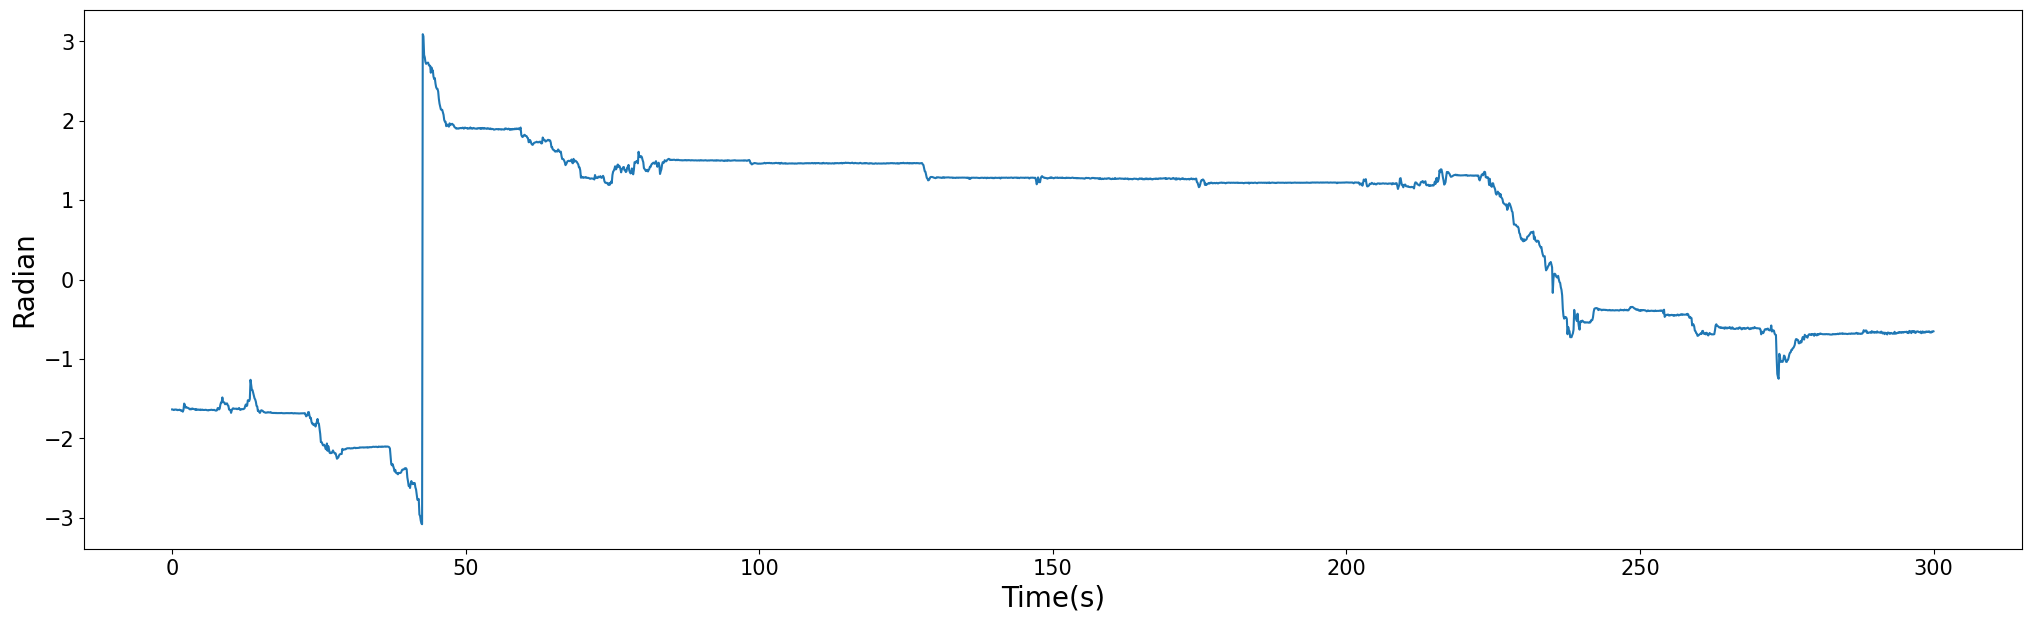

In [32]:
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging,forward_array_downsampled*np.pi*2/10-np.pi)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xlabel('Time(s)', fontsize=20)
plt.ylabel('Radian', fontsize=20)
plt.show()

In [33]:
head_array_downsampled_wrapped = head_array_downsampled*np.pi*2/10-np.pi
forward_array_downsampled_wrapped = forward_array_downsampled*np.pi*2/10-np.pi
barPosition_array_downsampled_wrapped = head_array_downsampled_wrapped

In [34]:
max_Voltage = 10
heading_array_processed = fictrack_signal_decoding(barPosition_array_downsampled_wrapped, time_array_imaging, max_Voltage, already_radian = True)
forward_array_processed = fictrack_signal_decoding(forward_array_downsampled_wrapped, time_array_imaging, max_Voltage, already_radian = True)

In [35]:
heading_velocity = np.gradient(heading_array_processed)/volume_time
abnormal_velocity = np.argwhere(np.absolute(heading_velocity) > 8.72)
while (len(abnormal_velocity ) > 0):
    heading_velocity[abnormal_velocity ] = heading_velocity[abnormal_velocity -1]
    abnormal_velocity = np.argwhere(np.absolute(heading_velocity) > 8.72)

In [36]:
Angular_speed_radian = np.abs(heading_velocity)
Angular_speed_degrees = Angular_speed_radian*180/np.pi
Forward_velocity = np.gradient(forward_array_processed)/volume_time
Forward_speed_radian = np.abs(Forward_velocity)
Forward_speed_degrees =Forward_speed_radian * 180/np.pi

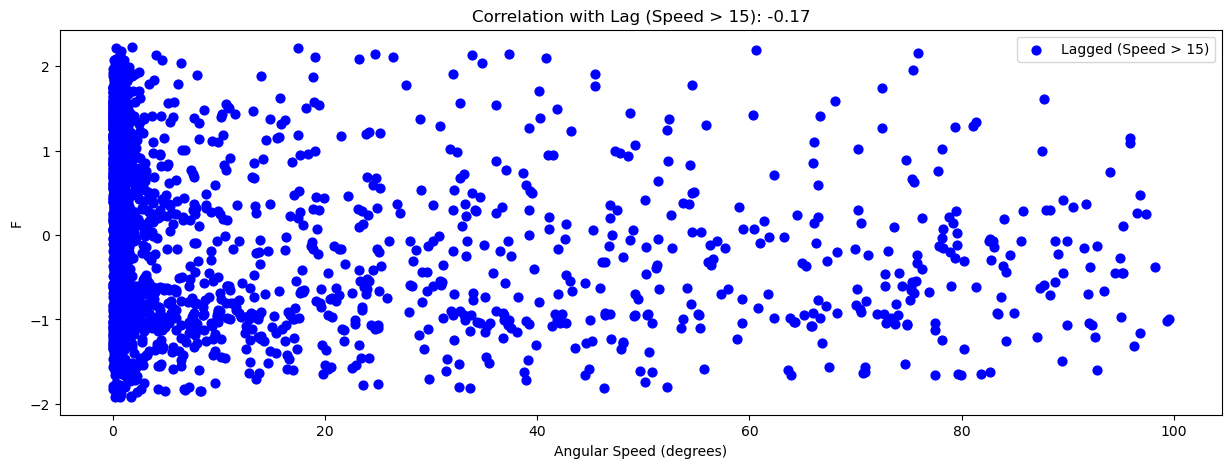

In [37]:
from scipy.signal import correlate
from scipy.stats import zscore
from scipy.signal import correlation_lags
from scipy.signal import correlate
#F_array_bg_subtracted
Signal_array_smooth_for_speed_cor = gaussian_filter1d(np.squeeze(F_array_bg_subtracted[:,0]), sigma =6)
Signal_array_z_smooth_for_speed_cor = zscore(Signal_array_smooth_for_speed_cor)


# Calculate cross-correlation within the allowed lags range
cross_corr = correlate(Angular_speed_degrees, Signal_array_z_smooth_for_speed_cor, mode='full')
lags = correlation_lags(Angular_speed_degrees.size,  Signal_array_z_smooth_for_speed_cor.size, mode="full")
                                  
#find the middle index to consider the frame on both side till max shift frame (1s)
max_shift_frame = int(volume_rate)
middle_index = int(len(lags)/2)
lags_short = lags[(middle_index - max_shift_frame):(middle_index + max_shift_frame + 1) ]
correlation_short = cross_corr[(middle_index - max_shift_frame):(middle_index + max_shift_frame + 1) ]
lag = lags_short[np.argmax(correlation_short)]
if lag > 0:
    lag = lags_short[np.argmax(correlation_short[0:int((len(correlation_short)-1)/2+1)])]
lag = int(-0.4/volume_time)
    
# Apply the lag only to Bump_amplitude_z_smooth_for_speed_cor
    
#shift back tne bump_amplitude by drop the lag frame at the beginning
lagged_Signal_array_z_smooth_for_speed_cor = Signal_array_z_smooth_for_speed_cor[-lag:]
angular_speed_degrees_shifted = Angular_speed_degrees[:len(lagged_Signal_array_z_smooth_for_speed_cor)]
# Create a mask for data points where Forward_speed_degrees > 15
mask = (angular_speed_degrees_shifted > 0) & (angular_speed_degrees_shifted < 100)

# Apply the mask to both time series
masked_angular_speed = angular_speed_degrees_shifted[mask]
masked_lagged_Signal_array_z_smooth_for_speed_cor = lagged_Signal_array_z_smooth_for_speed_cor[mask]

# Now you can calculate the correlation with lag accounted for and the mask
correlation_coefficient = np.corrcoef(masked_angular_speed, masked_lagged_Signal_array_z_smooth_for_speed_cor)[0, 1]

# Plot the original and lagged time series for visualization
plt.figure(figsize=(15, 5))
plt.scatter(masked_angular_speed, masked_lagged_Signal_array_z_smooth_for_speed_cor, color='blue', s=40, label='Lagged (Speed > 15)')
plt.legend()
plt.xlabel('Angular Speed (degrees)')
plt.ylabel('F')
plt.title(f'Correlation with Lag (Speed > 15): {correlation_coefficient:.2f}')
plt.show()

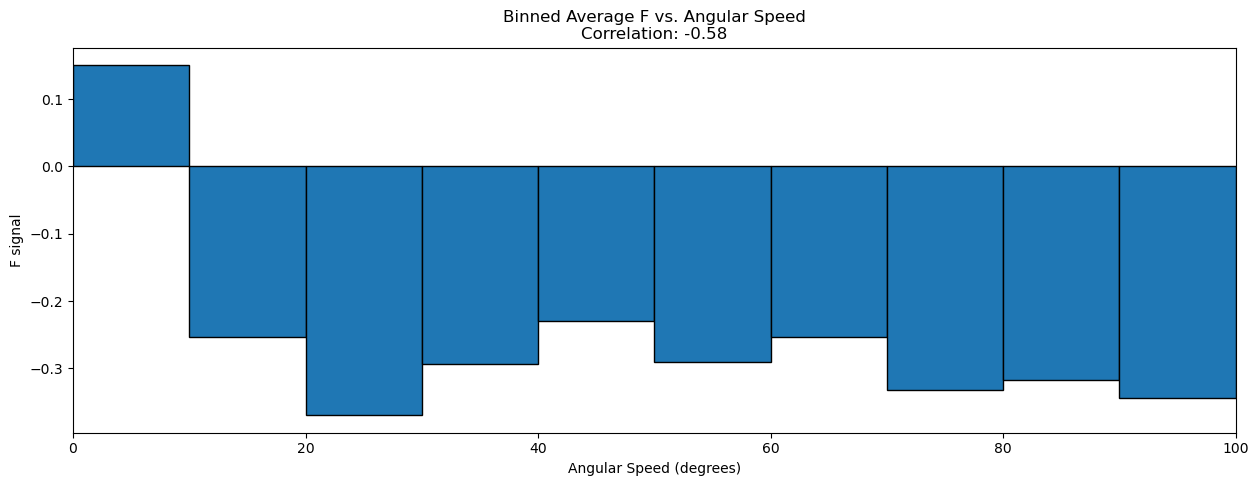

In [38]:
from scipy.stats import binned_statistic

# Define the bin edges with a bin width of 5
bin_width = 10
bin_edges = np.arange(0, 100 + bin_width, bin_width)

# Use scipy's binned_statistic to calculate the mean bump amplitude for each bin
binned_stats = binned_statistic(angular_speed_degrees_shifted, lagged_Signal_array_z_smooth_for_speed_cor, statistic='mean', bins=bin_edges)

# Extract the mean bump amplitude and bin centers
mean_Signal_array_per_bin = binned_stats.statistic
bin_centers = binned_stats.bin_edges[:-1] + 0.5 * bin_width

# Exclude bins with no data points
valid_bins = ~np.isnan(mean_Signal_array_per_bin)

# Calculate the correlation between mean bump amplitude and bin centers for valid bins
correlation_coefficient = np.corrcoef(bin_centers[valid_bins], mean_Signal_array_per_bin[valid_bins])[0, 1]

# Plot the binned mean bump amplitude against the angular speed for valid bins
plt.figure(figsize=(15, 5))
plt.bar(bin_centers[valid_bins], mean_Signal_array_per_bin[valid_bins], width=bin_width, align='center', edgecolor='black')
plt.xlim(0, np.max(bin_edges))  # Set the limit for angular speed
plt.xlabel('Angular Speed (degrees)')
plt.ylabel('F signal')
plt.title(f'Binned Average F vs. Angular Speed\nCorrelation: {correlation_coefficient:.2f}')
plt.show()

In [39]:
from scipy.signal import correlate, correlation_lags
from scipy.stats import zscore, binned_statistic
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def analyze_correlation(variable_x, variable_y, volume_rate, volume_time, bin_width=1,
                         angular_speed_limits=(0, 100), smoothing_sigma=6, max_shift_time=1):
    """
    Analyze the correlation between two variables, including cross-correlation and binned statistics.

    Parameters:
        variable_x (array): The first variable (e.g., Angular Speed).
        variable_y (array): The second variable (e.g., F signal).
        volume_rate (float): Sampling rate of the data.
        volume_time (float): Time per volume.
        bin_width (float): Bin width for binned statistics (default is 1).
        angular_speed_limits (tuple): Limits for filtering angular speed (min, max).
        smoothing_sigma (float): Sigma for Gaussian smoothing of variable_y.
        max_shift_time (float): Maximum shift time (in seconds) to consider for cross-correlation.

    Returns:
        dict: Results including correlation coefficient, binned data, and plots.
    """
    # Smooth and z-score the second variable
    variable_y_smooth = gaussian_filter1d(np.squeeze(variable_y), sigma=smoothing_sigma)
    variable_y_z = zscore(variable_y_smooth)

    # Calculate cross-correlation
    cross_corr = correlate(variable_x, variable_y_z, mode='full')
    lags = correlation_lags(len(variable_x), len(variable_y_z), mode="full")

    # Determine allowed lag range
    max_shift_frames = int(volume_rate * max_shift_time)
    middle_index = len(lags) // 2
    lags_short = lags[middle_index - max_shift_frames: middle_index + max_shift_frames + 1]
    correlation_short = cross_corr[middle_index - max_shift_frames: middle_index + max_shift_frames + 1]

    # Find the optimal lag
    optimal_lag = lags_short[np.argmax(correlation_short)]

    # Apply lag to the second variable
    if optimal_lag > 0:
        variable_y_lagged = variable_y_z[:-optimal_lag]
        variable_x_shifted = variable_x[optimal_lag:]
    else:
        variable_y_lagged = variable_y_z[-optimal_lag:]
        variable_x_shifted = variable_x[:len(variable_y_lagged)]

    # Create a mask based on angular speed limits
    mask = (variable_x_shifted > angular_speed_limits[0]) & (variable_x_shifted < angular_speed_limits[1])

    # Apply the mask
    masked_x = variable_x_shifted[mask]
    masked_y = variable_y_lagged[mask]

    # Calculate Pearson correlation for masked data
    correlation_coefficient = np.corrcoef(masked_x, masked_y)[0, 1]

    # Plot cross-correlation results
    plt.figure(figsize=(15, 5))
    plt.scatter(masked_x, masked_y, color='blue', s=40, label=f'Lagged ({angular_speed_limits[0]} < Speed < {angular_speed_limits[1]})')
    plt.legend()
    plt.xlabel('Variable X')
    plt.ylabel('Variable Y')
    plt.title(f'Correlation with Lag: {correlation_coefficient:.2f}')
    plt.show()

    # Calculate binned statistics
    bin_edges = np.arange(angular_speed_limits[0], angular_speed_limits[1] + bin_width, bin_width)
    binned_stats = binned_statistic(masked_x, masked_y, statistic='mean', bins=bin_edges)

    mean_per_bin = binned_stats.statistic
    bin_centers = binned_stats.bin_edges[:-1] + 0.5 * bin_width

    # Exclude bins with no data points
    valid_bins = ~np.isnan(mean_per_bin)

    # Calculate correlation for binned data
    binned_correlation = np.corrcoef(bin_centers[valid_bins], mean_per_bin[valid_bins])[0, 1]

    # Plot binned statistics
    plt.figure(figsize=(15, 5))
    plt.bar(bin_centers[valid_bins], mean_per_bin[valid_bins], width=bin_width, align='center', edgecolor='black')
    plt.xlim(angular_speed_limits[0], angular_speed_limits[1])
    plt.xlabel('Binned Variable X')
    plt.ylabel('Mean Variable Y per Bin')
    plt.title(f'Binned Average Y vs. Binned X\nCorrelation: {binned_correlation:.2f}')
    plt.show()

    # Return results
    return {
        'correlation_coefficient': correlation_coefficient,
        'binned_correlation': binned_correlation,
        'optimal_lag': optimal_lag,
        'masked_x': masked_x,
        'masked_y': masked_y,
        'mean_per_bin': mean_per_bin,
        'bin_centers': bin_centers[valid_bins]
    }

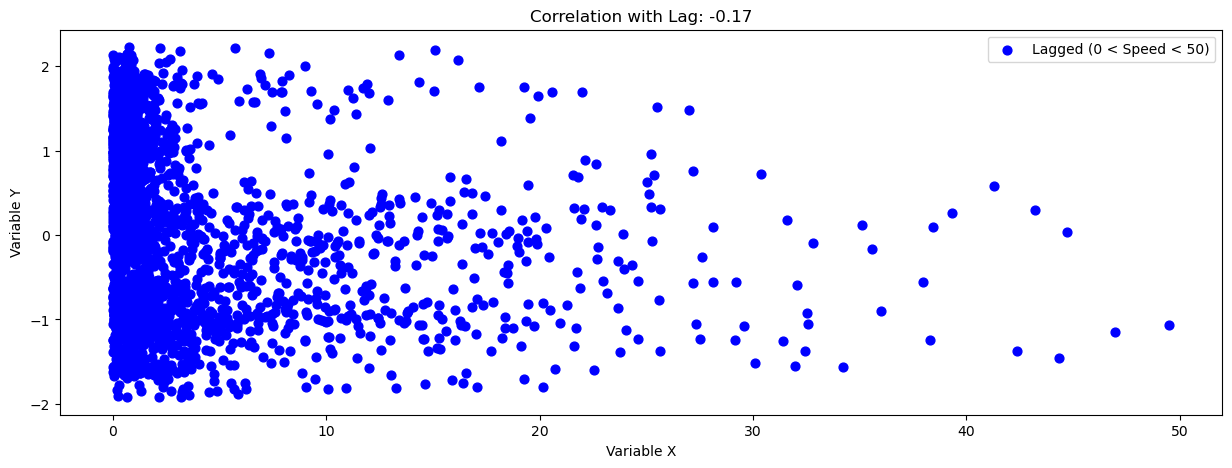

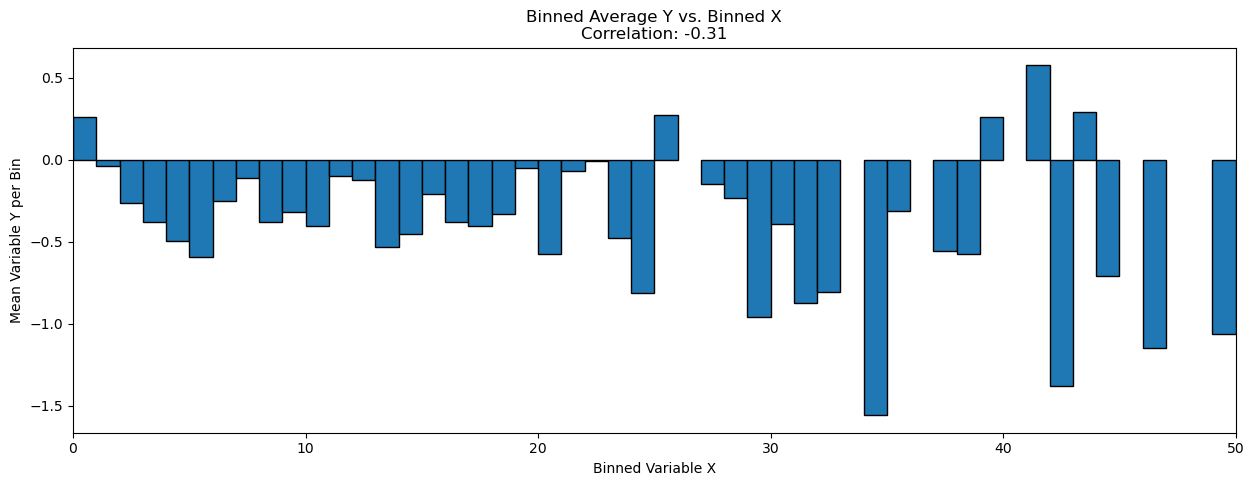

{'correlation_coefficient': -0.16582807067834052,
 'binned_correlation': -0.30884689808845806,
 'optimal_lag': 8,
 'masked_x': array([1.18595531, 0.32949016, 0.85080722, ..., 2.67126369, 0.03250154,
        1.49823003]),
 'masked_y': array([-0.62764391, -0.6282814 , -0.62995444, ..., -1.23024245,
        -1.24843942, -1.26618457]),
 'mean_per_bin': array([ 0.25719923, -0.04174629, -0.26208717, -0.38081448, -0.49768822,
        -0.59401988, -0.25472621, -0.11344982, -0.37835809, -0.31994315,
        -0.40416891, -0.09860415, -0.12556106, -0.53454014, -0.45182597,
        -0.20908497, -0.37827902, -0.40208425, -0.33239407, -0.05176634,
        -0.57636477, -0.06992912, -0.00989426, -0.47631878, -0.81338824,
         0.27368124,         nan, -0.14704053, -0.23182332, -0.95685404,
        -0.39487139, -0.87495453, -0.80912651,         nan, -1.55832528,
        -0.31115879,         nan, -0.55958592, -0.57550353,  0.26137546,
                nan,  0.57566489, -1.37793273,  0.29144329, -0.711

In [40]:
analyze_correlation(Forward_speed_degrees, F_array_bg_subtracted[:,0], volume_rate, volume_time, bin_width=1,
                         angular_speed_limits=(0, 50), smoothing_sigma=6, max_shift_time=1)

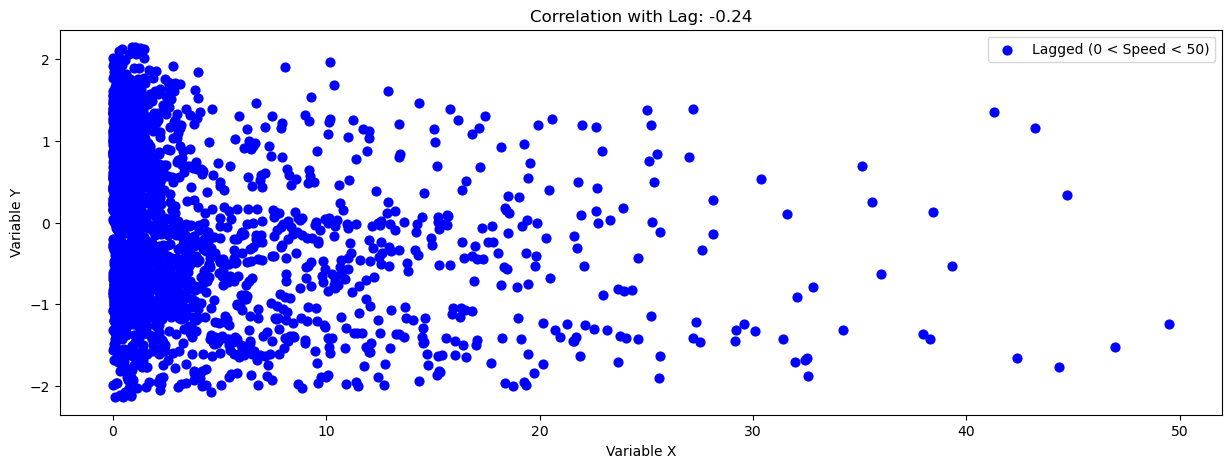

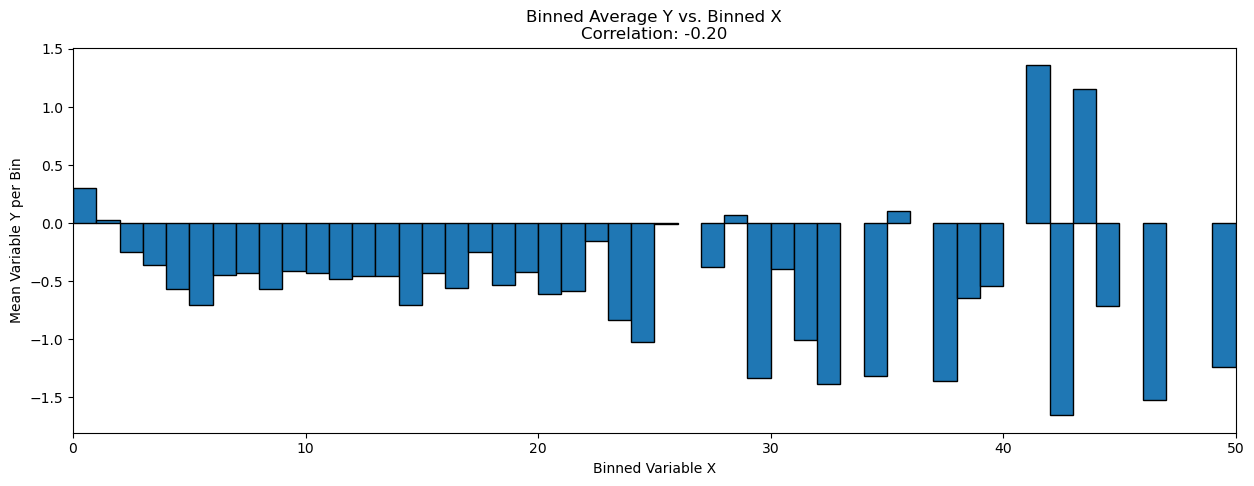

{'correlation_coefficient': -0.24164884065954872,
 'binned_correlation': -0.19729648894270457,
 'optimal_lag': -8,
 'masked_x': array([0.08832922, 1.59754064, 1.76703707, ..., 0.50777692, 0.18241622,
        0.69187966]),
 'masked_y': array([-0.97514254, -1.02921972, -1.0979716 , ..., -0.84381493,
        -0.85684249, -0.86352911]),
 'mean_per_bin': array([ 0.30224836,  0.0262857 , -0.25132747, -0.35916095, -0.56515259,
        -0.70396039, -0.44384615, -0.43125331, -0.56387038, -0.41122836,
        -0.42760166, -0.4774173 , -0.45369958, -0.4587503 , -0.7061515 ,
        -0.42917239, -0.55392843, -0.24678304, -0.53496635, -0.42162276,
        -0.60998572, -0.58686688, -0.15195228, -0.8338747 , -1.02061518,
        -0.011064  ,         nan, -0.37481523,  0.07148044, -1.33601016,
        -0.39552477, -1.00905645, -1.38204444,         nan, -1.31191087,
         0.10544761,         nan, -1.3590652 , -0.64385312, -0.53729225,
                nan,  1.36001538, -1.6536285 ,  1.15859829, -0.71

In [41]:
analyze_correlation(Forward_speed_degrees, F_array_bg_subtracted[:,1], volume_rate, volume_time, bin_width=1,
                         angular_speed_limits=(0, 50), smoothing_sigma=6, max_shift_time=1)

In [42]:
#find stop period and plot as shaded under unwrapped PVA/behavior
persistence_stop_index_and_length = find_stop_period_on_heading(head_velocity_array = heading_velocity,degree_of_tolerance =15,shortest_stopFrame=int(np.ceil(3/volume_time)))

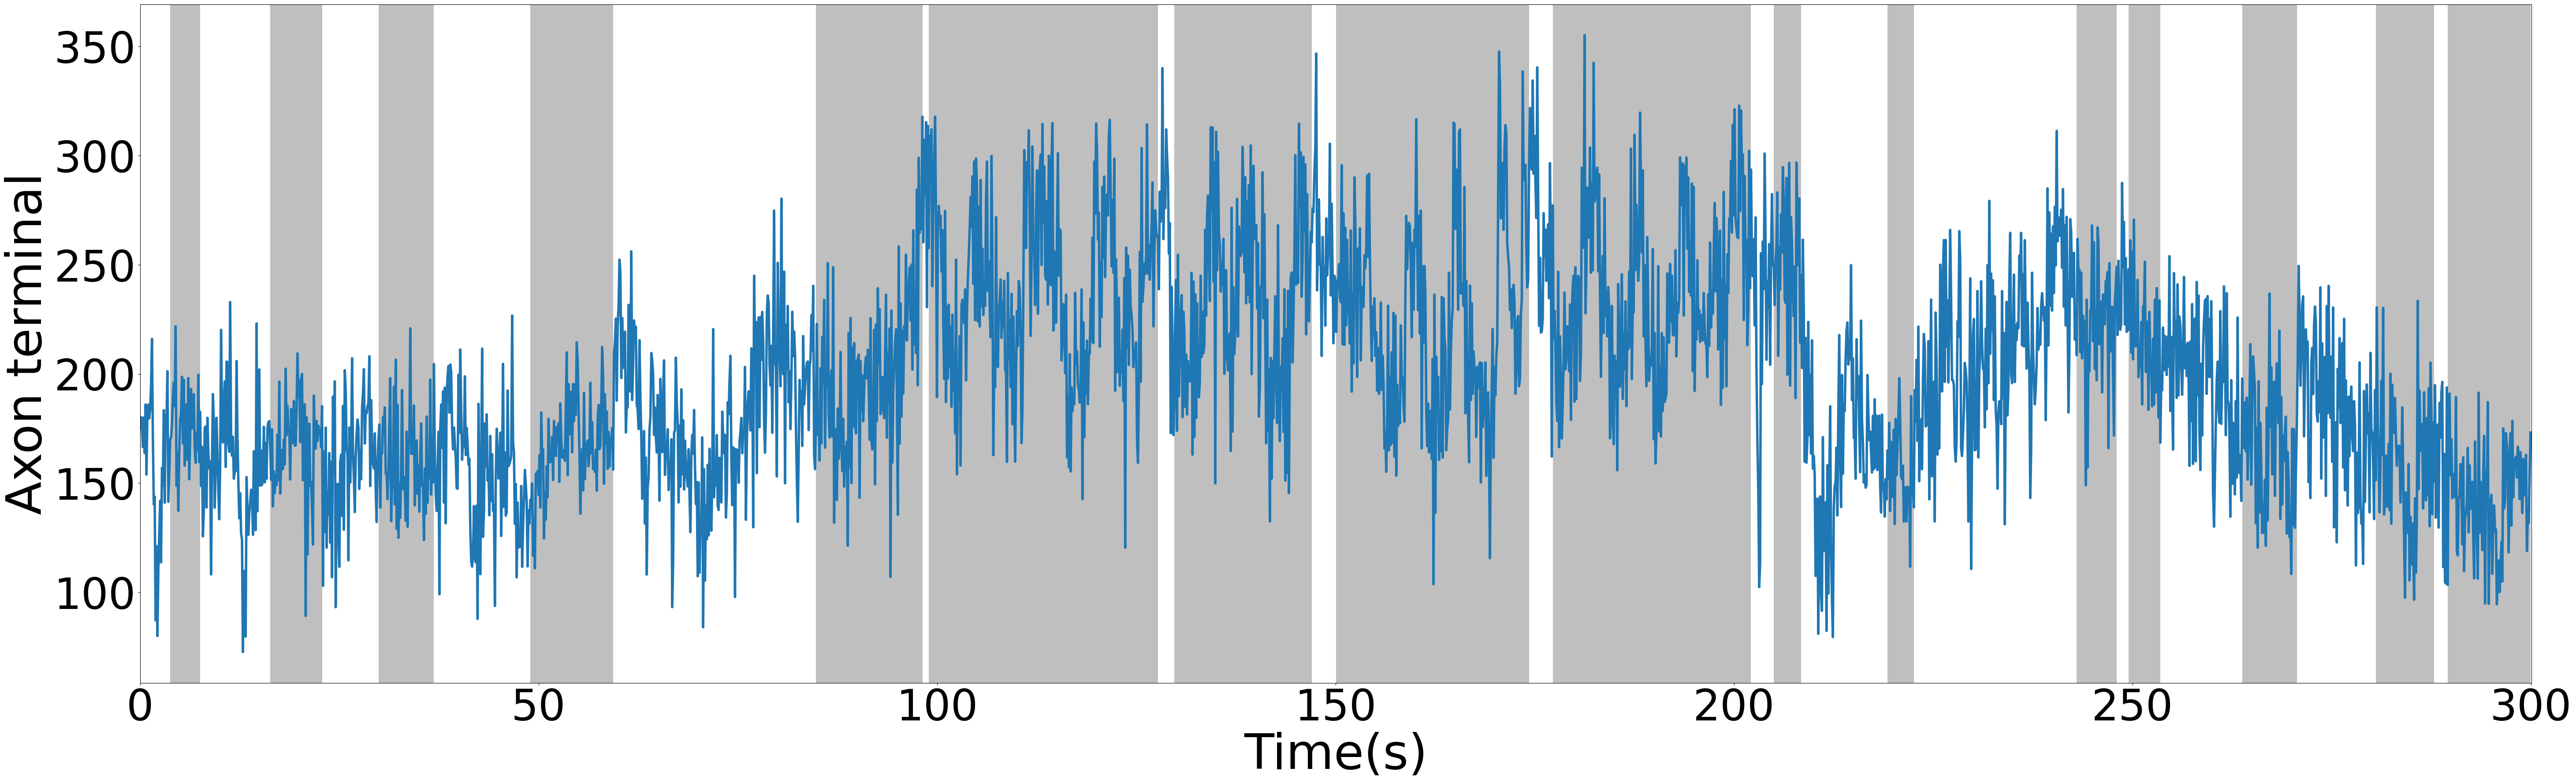

In [43]:
plt.figure(figsize= (70,20))
#plt.plot(time_array_imaging,F_array_bg_subtracted ,linewidth =4)
plt.plot(time_array_imaging,F_array_bg_subtracted[:,0] ,linewidth =4)
for i in range(len(persistence_stop_index_and_length)):
    plt.axvspan((persistence_stop_index_and_length[i,0]-persistence_stop_index_and_length[i,1])*volume_time, persistence_stop_index_and_length[i,0]*volume_time, color = 'grey', alpha = 0.5, lw =0,label = 'Standing')
plt.xlabel('Time(s)', fontsize=80)
plt.xticks(fontsize=70)
plt.yticks(fontsize=70)
plt.xlim(0,volume_cycle*volume_time)
plt.ylabel('Axon terminal', fontsize=80)
plt.show()

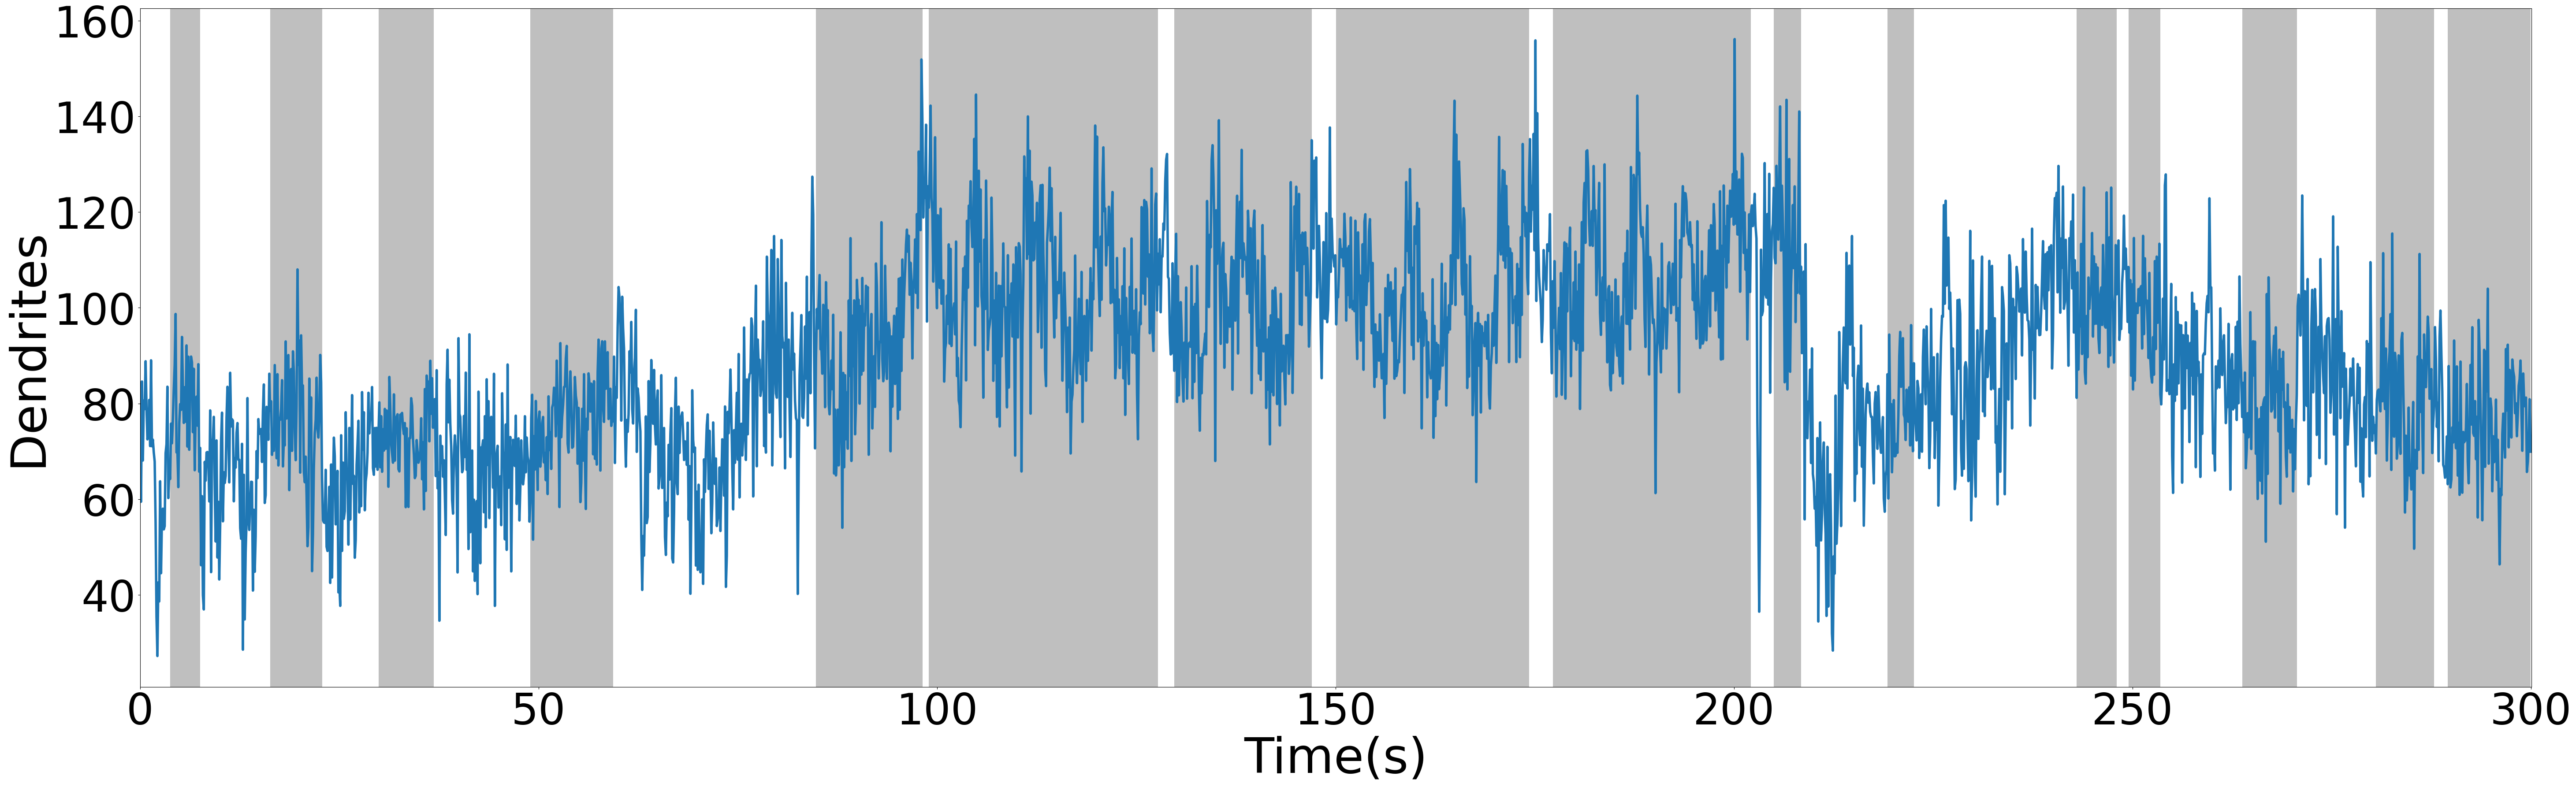

In [44]:
plt.figure(figsize= (70,20))
#plt.plot(time_array_imaging,F_array_bg_subtracted ,linewidth =4)
plt.plot(time_array_imaging,F_array_bg_subtracted[:,1] ,linewidth =4)
for i in range(len(persistence_stop_index_and_length)):
    plt.axvspan((persistence_stop_index_and_length[i,0]-persistence_stop_index_and_length[i,1])*volume_time, persistence_stop_index_and_length[i,0]*volume_time, color = 'grey', alpha = 0.5, lw =0,label = 'Standing')
plt.xlabel('Time(s)', fontsize=80)
plt.xticks(fontsize=70)
plt.yticks(fontsize=70)
plt.xlim(0,volume_cycle*volume_time)
plt.ylabel('Dendrites', fontsize=80)
plt.show()

In [45]:
PVA_behavior_data_output_normalized = pd.DataFrame()
PVA_behavior_data_output_normalized['Time_Stamp'] = time_array_imaging
PVA_behavior_data_output_normalized['Raw_F_axon'] = F_array[:,0]
PVA_behavior_data_output_normalized['Raw_F_dewndrites'] = F_array[:,1]
PVA_behavior_data_output_normalized['F_background_subtracted_axon']= F_array_bg_subtracted[:,0]
PVA_behavior_data_output_normalized['F_background_subtracted_dendrites']= F_array_bg_subtracted[:,1]
PVA_behavior_data_output_normalized['background_signal'] = F_array_background[:,0]
PVA_behavior_data_output_normalized['dFF_Roi_1'] = dF_F_array[:,0]
PVA_behavior_data_output_normalized['Z_score_Roi_1'] = Z_score_array[:,0]
PVA_behavior_data_output_normalized['dFF_Roi_2'] = dF_F_array[:,1]
PVA_behavior_data_output_normalized['Z_score_Roi_2'] = Z_score_array[:,1]
PVA_behavior_data_output_normalized['Angular_Velocity'] = heading_velocity
PVA_behavior_data_output_normalized['Forward_Velocity'] = Forward_velocity
PVA_behavior_data_output_normalized['Bar_Position/Heading'] = barPosition_array_downsampled_wrapped
PVA_behavior_data_output_normalized['Unwrapped_Bar_Position/Heading'] = heading_array_processed
PVA_behavior_data_output_normalized['Forward'] = forward_array_downsampled

In [46]:
PVA_behavior_data_output_normalized

,Time_Stamp,Raw_F_axon,Raw_F_dewndrites,F_background_subtracted_axon,F_background_subtracted_dendrites,background_signal,dFF_Roi_1,Z_score_Roi_1,dFF_Roi_2,Z_score_Roi_2,Angular_Velocity,Forward_Velocity,Bar_Position/Heading,Unwrapped_Bar_Position/Heading,Forward
0,0.00000,190.770430,86.889159,174.983352,71.102082,15.787078,0.300801,-0.525844,0.144644,-0.975972,0.014403,0.001542,1.084964,1.084964,2.395336
1,0.11414,202.748501,81.994958,180.212198,59.458655,22.536303,0.382476,-0.272796,0.080169,-1.231554,0.002412,-0.027882,1.086608,1.086608,2.395616
2,0.22828,202.281480,110.652786,176.211159,84.582465,26.070321,0.379291,-0.282662,0.457696,0.264993,-0.013116,-0.030841,1.085515,1.085515,2.385206
3,0.34242,179.953572,81.472399,166.564602,68.083428,13.388970,0.227045,-0.754361,0.073285,-1.258842,-0.009418,0.024762,1.083614,1.083614,2.384411
4,0.45656,193.622923,94.075111,180.139810,80.591998,13.483113,0.320251,-0.465583,0.239308,-0.600713,0.005018,0.025786,1.083365,1.083365,2.394202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2624,299.50336,142.315573,89.082239,118.920403,65.687069,23.395171,-0.029597,-1.549501,0.173534,-0.861447,-0.004205,0.006949,1.172029,51.437511,3.941086
2625,299.61750,154.256125,86.344258,135.796017,67.884150,18.460108,0.051822,-1.297245,0.137465,-1.004428,0.000261,0.056075,1.171644,51.437127,3.939564
2626,299.73164,145.293987,85.978527,131.819032,72.503572,13.474955,-0.009288,-1.486579,0.132647,-1.023527,-0.006170,0.046622,1.172089,51.437571,3.961459
2627,299.84578,172.408772,100.360428,152.934632,80.886288,19.474139,0.175599,-0.913753,0.322109,-0.272486,-0.005624,-0.000567,1.170236,51.435718,3.956503


In [47]:
PVA_behavior_data_output_normalized.to_csv('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/R55G08_SPARC_S_ASAP7y/TQfly006-006-imaging-delta7_ASAP7y.csv',encoding = 'utf-8', index=False)